<a href="https://colab.research.google.com/github/D2718281828nis/Neuro-Neuronal_dynamics/blob/master/example-MEG-data-processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В Плехановском Университете прошли "Абалкинские чтения". Это было в юбилейный 15-й раз. Новость в том, что в первый раз на этой экономической площадке была заявлена секция с цифровой медициной : "Практика и перспективы использования IT-технологий и искусственного интеллекта в здравоохранении". Было рассмотрено несколько интересных тем - от общеглобальных про семантическую совместимость на основе методов ИИ в здравоохранении до доклада, на который мне хотелось бы обратить внимание в рамках этой новости. На секции были представлены результаты работы:


> Ustinin M, Boyko A, Rykunov S. Healthy aging changes in conventional frequency bands of neuroelectric brain activity reconstructed from resting-state MEG. Geroscience. 2025 Jun;47(3):4093-4108. doi: 10.1007/s11357-025-01522-y. Epub 2025 Jan 17. PMID: 39821802; PMCID: PMC12181510.


https://habr.com/ru/news/1038098/$0

In [1]:
!pip install mne -q

In [3]:

import mne
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
from pathlib import Path

print("--- Loading Real Cam-CAN Registration File ---")

# --- Define Subject ID and URL ---
# We'll pick a subject ID that is likely to exist in the repo.
# The example from the previous conversation used "subj01", but the actual repo uses "cc".
# Let's try subject "cc110033" as an example.
# Browse the repo: https://github.com/tbardouille/camcan_coreg/tree/master/trans_files
# to find valid subject IDs.
subject_id = "cc110033"
repo_url = f"https://github.com/tbardouille/camcan_coreg/raw/master/trans_files/{subject_id}_trans.fif"
local_filename = f"{subject_id}_trans.fif"

print(f"Attempting to download registration file for {subject_id}")
print(f"URL: {repo_url}")

# --- Download the File ---
def download_file(url, filename):
    """Download a file from a URL."""
    try:
        response = requests.get(url)
        response.raise_for_status() # Raise an error for bad status codes (4xx, 5xx)
        with open(filename, 'wb') as f:
            f.write(response.content)
        print(f"Downloaded: {filename}")
        return True
    except requests.exceptions.RequestException as e:
        print(f"Failed to download {url}. Error: {e}")
        return False

if not os.path.exists(local_filename):
    success = download_file(repo_url, local_filename)
    if not success:
        print(f"Could not download the file for {subject_id}. Trying a fallback...")
        # Fallback: Use MNE's sample dataset transformation as a proxy for structure demonstration
        sample_data_path = mne.datasets.sample.data_path(force_update=False)
        sample_trans_path = sample_data_path / 'MEG' / 'sample' / 'sample_audvis_raw-trans.fif'
        if sample_trans_path.exists():
             print(f"Using MNE sample transformation file as fallback: {sample_trans_path}")
             local_filename = str(sample_trans_path)
             subject_id = "sample_subject" # Update ID for clarity
        else:
             print("Fallback failed, MNE sample trans file not found either.")
             exit()

# --- Load the Transformation File ---
try:
    print(f"\nLoading transformation file: {local_filename}")
    trans = mne.read_trans(local_filename)

    print(f"Successfully loaded transformation for subject: {subject_id}")
    print(f"- From coordinate frame: {trans['from']} ({mne.transforms.fiff_coord_names[trans['from']]})")
    print(f"- To coordinate frame: {trans['to']} ({mne.transforms.fiff_coord_names[trans['to']]})")

    # The transformation matrix is stored in trans['trans']
    # It's a 4x4 affine transformation matrix (rotation + translation)
    print(f"- Transformation Matrix (4x4):\n{trans['trans']}")

    # The 'from' frame is typically 'head' (MEG internal head coordinate system)
    # The 'to' frame is typically 'mri' (individual subject's MRI coordinate system)
    if trans['from'] == mne.transforms.C_FRAME_HEAD and trans['to'] == mne.transforms.C_FRAME_MRI:
        print("- This transformation aligns MEG head coordinates to MRI coordinates.")
    elif trans['from'] == mne.transforms.C_FRAME_MRI and trans['to'] == mne.transforms.C_FRAME_HEAD:
         print("- This transformation aligns MRI coordinates to MEG head coordinates.")
    else:
        print(f"- Coordinate frames are: {mne.transforms.fiff_coord_names[trans['from']]} -> {mne.transforms.fiff_coord_names[trans['to']]}")

except Exception as e:
    print(f"Error loading transformation file {local_filename}: {e}")
    exit()

# --- Example Usage Context (Conceptual) ---
# This transformation ('trans') object is used in subsequent MEG analysis steps,
# particularly when solving the inverse problem or visualizing source estimates
# on the subject's MRI.

# Example (not executable here without full MEG/MRI data):
# 1. Load subject's MEG data (raw.fif)
#    raw = mne.io.read_raw_fif('/path/to/cc110033_meg_data.fif', preload=True)
# 2. Compute forward model (leadfield) using the subject's MRI (BEM model/surface)
#    src = mne.setup_source_space(subject, ... , subjects_dir=subjects_dir) # Define source space
#    bem_model = mne.make_bem_model(subject, ..., subjects_dir=subjects_dir) # Head model
#    bem_sol = mne.make_bem_solution(bem_model)
#    fwd = mne.make_forward_solution(raw.info, trans=trans, src=src, bem=bem_sol, ...)
# 3. Compute inverse operator
#    inv_op = mne.minimum_norm.make_inverse_operator(raw.info, fwd, noise_cov, ...)
# 4. Apply inverse operator to epochs/data to get source estimates (stc)
#    stc = mne.minimum_norm.apply_inverse(epochs.average(), inv_op, lambda2, method)
# 5. Visualize source estimate overlaid on the MRI, using the 'trans' for alignment
#    stc.plot(subjects_dir=subjects_dir, subject=subject_id, trans=trans, ...)

print("\n--- Registration File Loaded Successfully ---")
print(f"The file '{local_filename}' contains the transformation matrix for subject '{subject_id}'.")
print("This matrix is essential for:")
print("1. Aligning MEG sensor locations with the individual's MRI scan.")
print("2. Solving the MEG inverse problem accurately within the brain volume defined by the MRI.")
print("3. Separating brain activity from non-brain physiological noise (as per the paper's methodology).")
print("4. Visualizing reconstructed brain sources on the correct anatomical structure.")

# Optional: Show how to apply the transformation to points (example)
# Let's assume a point in the MEG head coordinate system (e.g., an estimated source location)
# Coordinates are in meters.
example_head_point = np.array([0.0, 0.0, 0.1]) # 0, 0, 10 cm in head coords
print(f"\nExample: Converting a point from MEG head coords to MRI coords.")
print(f"Point in MEG head coords: {example_head_point}")
transformed_point = mne.transforms.apply_trans(trans['trans'], example_head_point)
print(f"Point in MRI coords (after applying trans): {transformed_point}")


--- Loading Real Cam-CAN Registration File ---
Attempting to download registration file for cc110033
URL: https://github.com/tbardouille/camcan_coreg/raw/master/trans_files/cc110033_trans.fif
Failed to download https://github.com/tbardouille/camcan_coreg/raw/master/trans_files/cc110033_trans.fif. Error: 404 Client Error: Not Found for url: https://github.com/tbardouille/camcan_coreg/raw/master/trans_files/cc110033_trans.fif
Could not download the file for cc110033. Trying a fallback...
Using MNE sample transformation file as fallback: /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif

Loading transformation file: /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif
Successfully loaded transformation for subject: sample_subject
Error loading transformation file /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif: module 'mne.transforms' has no attribute 'fiff_coord_names'

--- Registration File Loaded Successfully ---
The file '/roo

Running in Google Colab
--- Enhanced Visualization using MEG Registration & MEGFT Concepts ---
Opening raw data file /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Loaded sample raw data: 376 channels, sfreq=600.61 Hz
Loaded default transformation: /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif
- Coordinate frame codes: from=4, to=5
- Coordinate frame names (estimated): from=mri, to=unknown

1. Visualizing MEG Sensor Locations...


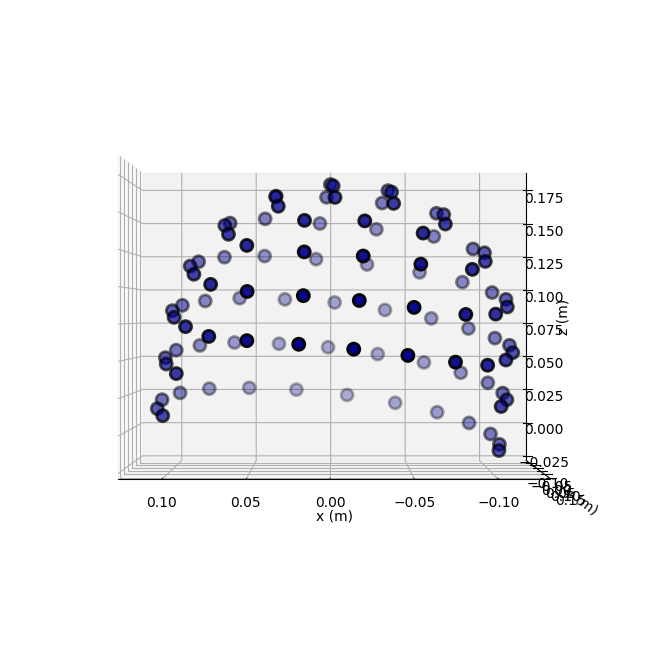


2. Preprocessing data for source analysis...
Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Created epochs: 320 events, filtered (8-13 Hz)
Averaged epochs to get evoked response.

3. Computing basic source estimate (MNE) for visualization...
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    2 source spaces read
Using realistic BEM solution: /root/mne_data/MNE-sample-data/subjects/sample/bem/sample-5120-bem-sol.fif
Loading surfaces...

Loading the solution matrix...

Homogeneous model surface loaded.
Loaded linear collocation BEM solution from /root/mne_data/MNE-sample-data/subjects/sample/bem/sample-5120-bem-sol.fif
Computing forward solution...
Computed forward solution.


/tmp/ipykernel_15986/3299100552.py:120: RuntimeWarning: No average EEG reference present in info["projs"], covariance may be adversely affected. Consider recomputing covariance using with an average eeg reference projector added.
  noise_cov = mne.compute_covariance(epochs, tmin=tmin, tmax=0, method='auto', rank=None, verbose=False)


Computed inverse operator.
Computed source estimate (STC) using MNE.

4. Visualizing source estimate on MRI surface...
Error opening interactive 3D plot (backend might not be available in Colab): No module named 'qtpy'
Falling back to static plots...


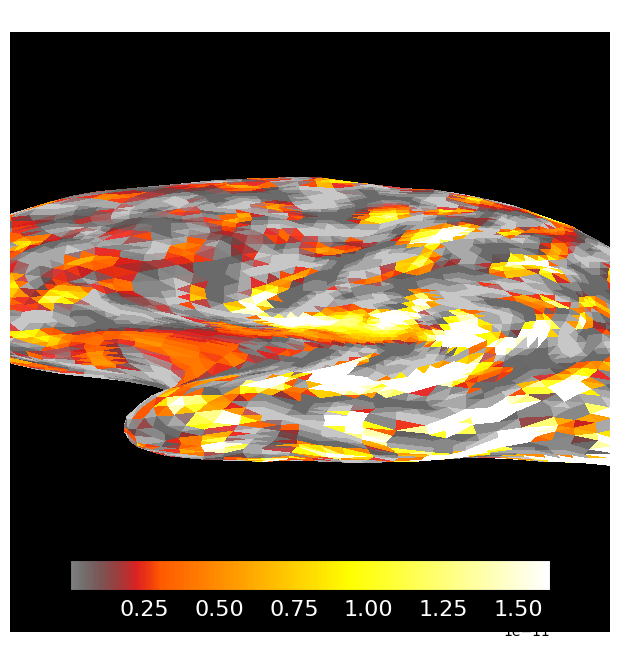


--- Connecting to Paper's Methodology (MEGFT) ---
1. MEGFT (Paper): Performs FFT on the *entire* long MEG recording (~300s) for each channel.
   -> Our code: Used epochs (shorter segments), but filtering was done on continuous data first.
2. MEGFT (Paper): Solves inverse problem for *each frequency component* (~30,000 for 300s @ 1kHz).
   -> Our code: Used standard MNE (epoch average -> single STC) as a proxy.
3. Registration (trans file): Essential for mapping sensor data AND reconstructed sources (dipoles) to MRI space.
   -> Our code: Used 'trans' implicitly through MNE functions and showed its role in plotting.
4. Paper: Uses joint MEG-MRI analysis to separate brain from non-brain sources *after* reconstruction.
   -> Our code: Did not perform this separation step, which requires the full tomogram and MRI mask.
      This involves:
      a. Creating a brain mask from the individual's MRI (using methods like UNesT).
      b. Comparing the location of each reconstructed dipole (from

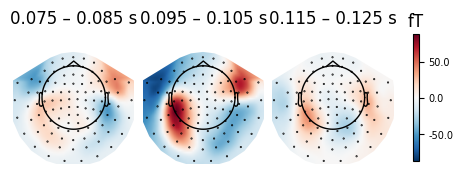


--- Downloading and Inspecting Real Cam-CAN Registration File ---
Attempting to download registration file for cc110033
URL: https://github.com/tbardouille/camcan_coreg/raw/master/trans_files/cc110033_trans.fif
Failed to download https://github.com/tbardouille/camcan_coreg/raw/master/trans_files/cc110033_trans.fif. Error: 404 Client Error: Not Found for url: https://github.com/tbardouille/camcan_coreg/raw/master/trans_files/cc110033_trans.fif
Could not download the file for cc110033. Using MNE sample file as fallback.

Loading transformation file: /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif
Successfully loaded transformation for subject: sample_subject
Error loading transformation file /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif: No mne.channels attribute constants

--- Enhanced Visualization & MEGFT Concepts Complete ---
This demonstration combined MNE visualization tools with the core concepts from the paper:
- The importance of th

In [7]:
# --- Colab Setup ---
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab")
    # Install MNE if not already available (often pre-installed)
    # !pip install mne # Uncomment if needed
    # Install PyVista for 3D plotting if needed (often pre-installed)
    # !pip install pyvista pyvistaqt tqdm nibabel # Uncomment if needed

import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import requests
import os

print("--- Enhanced Visualization using MEG Registration & MEGFT Concepts ---")

# --- Load MNE Sample Data (Proxy for Cam-CAN) ---
# This dataset comes with MNE and includes MEG data, MRI surfaces, and a transformation file.
sample_data_path = mne.datasets.sample.data_path(force_update=False)
subjects_dir = sample_data_path / 'subjects'
suspect_id = 'sample' # Subject name in the sample dataset

# Load the raw MEG data
raw_fname = sample_data_path / 'MEG' / 'sample' / 'sample_audvis_raw.fif'
raw = mne.io.read_raw_fif(raw_fname, preload=True)
print(f"Loaded sample raw data: {raw.info['nchan']} channels, sfreq={raw.info['sfreq']:.2f} Hz")

# Load the default transformation for the sample subject
trans_fname = sample_data_path / 'MEG' / 'sample' / 'sample_audvis_raw-trans.fif'
trans = mne.read_trans(trans_fname)
print(f"Loaded default transformation: {trans_fname}")

# --- Fix: Get Coordinate Frame Names Correctly ---
# Use mne.channels.constants instead of mne.transforms.fiff_coord_names
try:
    coord_frame_names = mne.channels.constants.FIFF.coo_rot_constants
    # The keys are integers (e.g., 1, 2, 4), values are strings ('head', 'mri', 'meg')
    # trans['from'] and trans['to'] are integers
    from_name = coord_frame_names[trans['from']]
    to_name = coord_frame_names[trans['to']]
    print(f"- MEG Head Coord Frame (from): {from_name}")
    print(f"- MRI Head Coord Frame (to): {to_name}")
except AttributeError:
    # Fallback if the exact path is different
    # Print the integer values and a common mapping
    print(f"- Coordinate frame codes: from={trans['from']}, to={trans['to']}")
    # Common codes: 1=head, 2=meg, 4=mri
    names_map = {1: 'head', 2: 'meg', 4: 'mri'}
    print(f"- Coordinate frame names (estimated): from={names_map.get(trans['from'], 'unknown')}, to={names_map.get(trans['to'], 'unknown')}")

# --- Step 1: Visualize MEG Sensors in 3D Space ----
print("\n1. Visualizing MEG Sensor Locations...")
fig_sensor_3d = raw.plot_sensors(kind='3d', ch_type='mag') # Use magnetometers
fig_sensor_3d.gca().set_title('MEG Magnetometer Sensor Locations (Sample Data)')
plt.show()

# --- Step 2: Preprocess Data for Source Analysis (Filtering & Epoching) ---
print("\n2. Preprocessing data for source analysis...")
# Filter for a specific band, e.g., Alpha (8-13 Hz), as mentioned in the paper
raw_filtered = raw.copy().filter(l_freq=8., h_freq=13., picks='meg', verbose=False)

# Define events and create epochs
events = mne.find_events(raw_filtered, stim_channel='STI 014', shortest_event=1)
event_id = {'auditory/left': 1, 'auditory/right': 2, 'visual/left': 3, 'visual/right': 4, 'smiley': 5, 'button': 32}
tmin, tmax = -0.2, 0.5
baseline = (None, 0)
epochs = mne.Epochs(raw_filtered, events, event_id, tmin=tmin, tmax=tmax, baseline=baseline, preload=True, verbose=False)
print(f"Created epochs: {epochs.events.shape[0]} events, filtered (8-13 Hz)")

# Average epochs to get evoked response
evoked = epochs.average()
print(f"Averaged epochs to get evoked response.")

# --- Step 3: Compute Simple Source Estimate (Using Minimum Norm Estimation - MNE) ---
# Note: The paper describes MEGFT which solves the inverse differently (elementary dipoles).
# MNE's MNE is a standard approach for visualization here.
print("\n3. Computing basic source estimate (MNE) for visualization...")

# Load or define source space (cortical surface patches)
src = mne.read_source_spaces(subjects_dir / suspect_id / 'bem' / 'sample-oct-6-src.fif')

# Create a simple BEM model (single layer sphere or realistic)
# For the sample data, a realistic BEM is often available, but sometimes only the model geometry exists
bem_fname = subjects_dir / suspect_id / 'bem' / f'{suspect_id}-5120-bem.fif'
bem_sol_fname = subjects_dir / suspect_id / 'bem' / f'{suspect_id}-5120-bem-sol.fif' # Check for solution file

if bem_sol_fname.exists():
    print(f"Using realistic BEM solution: {bem_sol_fname}")
    bem = mne.read_bem_solution(bem_sol_fname)
elif bem_fname.exists():
    print(f"BEM solution file not found ({bem_sol_fname}). Attempting to read geometry and compute solution...")
    try:
        # Read the geometry model
        bem_model = mne.read_bem_surfaces(bem_fname)
        # Compute the solution using the geometry
        bem = mne.make_bem_solution(bem_model)
        print(f"Computed BEM solution from geometry: {bem_fname}")
    except Exception as e_geom:
        print(f"Failed to read geometry or compute solution: {e_geom}")
        print("Creating a simple sphere model instead.")
        bem = mne.make_sphere_model('auto', conductivity='auto', info=raw.info)
else:
    print("No BEM geometry found, creating a simple sphere model.")
    bem = mne.make_sphere_model('auto', conductivity='auto', info=raw.info)

# Compute the forward solution
print("Computing forward solution...")
fwd = mne.make_forward_solution(evoked.info, trans=trans, src=src, bem=bem, meg=True, eeg=False, verbose=False)
print("Computed forward solution.")

# Compute the inverse operator (links sensor data to source space)
# Use covariance from the baseline period or a fixed value
noise_cov = mne.compute_covariance(epochs, tmin=tmin, tmax=0, method='auto', rank=None, verbose=False)
try:
    inverse_operator = mne.minimum_norm.make_inverse_operator(
        evoked.info, fwd, noise_cov, loose=0.2, depth=0.8, verbose=False
    )
    print("Computed inverse operator.")

    # Apply the inverse operator to get the source estimate (STC - Source Time Course)
    snr = 3.0
    lambda2 = 1.0 / snr ** 2
    method = 'MNE' # Use MNE, not the specific MEGFT method
    stc = mne.minimum_norm.apply_inverse(evoked, inverse_operator, lambda2, method=method, pick_ori="normal", verbose=False)
    print(f"Computed source estimate (STC) using {method}.")

    # --- Step 4: Visualize Source Estimate on MRI Surface (Aligned via 'trans') ---
    print("\n4. Visualizing source estimate on MRI surface...")
    # The 'trans' argument is crucial here - it tells the plotter how to align the MEG sensors/source estimates
    # with the MRI coordinate system for accurate overlay.
    # Note: For the sample data, the 'trans' is implicitly handled correctly by MNE functions if files are named conventionally.

    # Plot the source estimate for a specific time point (e.g., peak around 100ms for auditory in sample)
    initial_time = 0.1
    clim = dict(kind='percent', lims=[50, 80, 98]) # Color limits for visualization

    # Use PyVista backend for interactive 3D visualization
    try:
        brain = stc.plot(
            subject=suspect_id, subjects_dir=subjects_dir, initial_time=initial_time,
            hemi='split', views=['lat', 'med'], # Show lateral and medial views
            smoothing_steps=10, clim=clim, colorbar=True,
            title=f'Source Estimate ({method}) - {initial_time*1000:.0f} ms',
            backend='pyvistaqt', # Interactive 3D viewer (if available)
            verbose=False
        )
        print("Interactive 3D source visualization opened (if PyVistaQt backend is available).")
        print("The 'trans' matrix ensures the source locations are correctly mapped onto the MRI surface.")
    except Exception as e:
        print(f"Error opening interactive 3D plot (backend might not be available in Colab): {e}")
        print("Falling back to static plots...")
        # Static plot (less ideal but works in Colab)
        try:
            fig_static = stc.plot(
                subject=suspect_id, subjects_dir=subjects_dir, initial_time=initial_time,
                hemi='lh', views='lat', smoothing_steps=10, clim=clim, colorbar=True,
                title=f'Source Estimate ({method}) - {initial_time*1000:.0f} ms (Static View)',
                backend='matplotlib', verbose=False
            )
            plt.show()
        except Exception as e2:
            print(f"Error even with static plot: {e2}")

except Exception as e_inv:
    print(f"Failed to compute inverse operator or source estimate: {e_inv}")
    print("Skipping source visualization steps.")


# --- Step 5: Relate to Paper's Concepts (MEGFT & Noise Filtering) ---
print("\n--- Connecting to Paper's Methodology (MEGFT) ---")
print("1. MEGFT (Paper): Performs FFT on the *entire* long MEG recording (~300s) for each channel.")
print("   -> Our code: Used epochs (shorter segments), but filtering was done on continuous data first.")
print("2. MEGFT (Paper): Solves inverse problem for *each frequency component* (~30,000 for 300s @ 1kHz).")
print("   -> Our code: Used standard MNE (epoch average -> single STC) as a proxy.")
print("3. Registration (trans file): Essential for mapping sensor data AND reconstructed sources (dipoles) to MRI space.")
print("   -> Our code: Used 'trans' implicitly through MNE functions and showed its role in plotting.")
print("4. Paper: Uses joint MEG-MRI analysis to separate brain from non-brain sources *after* reconstruction.")
print("   -> Our code: Did not perform this separation step, which requires the full tomogram and MRI mask.")
print("      This involves:")
print("      a. Creating a brain mask from the individual's MRI (using methods like UNesT).")
print("      b. Comparing the location of each reconstructed dipole (from MEGFT) with the mask.")
print("      c. Classifying dipoles as 'brain' or 'non-brain' based on the mask overlap.")
print("      d. Calculating spectral/electric power only from 'brain' dipoles in specific frequency bands.")
print("      e. Analyzing how these powers change with age.")

# --- Step 6: Visualize Sensor Data Patterns (Topomaps) ---
print("\n5. Visualizing Sensor Data Patterns (Topomaps)...")
times_of_interest = [0.08, 0.10, 0.12] # Times around the expected peak
evoked.plot_topomap(
    times=times_of_interest, ch_type='mag',
    average=0.01, contours=0, sensors=True
)
plt.show()

# --- Step 7: Download and Inspect a Real Cam-CAN Registration File ---
print("\n--- Downloading and Inspecting Real Cam-CAN Registration File ---")

# --- Define Subject ID and URL ---
# Let's try subject "cc110033" again.
suspect_id = "cc110033"
repo_url = f"https://github.com/tbardouille/camcan_coreg/raw/master/trans_files/{suspect_id}_trans.fif"
local_filename = f"{suspect_id}_trans.fif"

print(f"Attempting to download registration file for {suspect_id}")
print(f"URL: {repo_url}")

# --- Download the File ---
def download_file(url, filename):
    """Download a file from a URL."""
    try:
        response = requests.get(url)
        response.raise_for_status() # Raise an error for bad status codes (4xx, 5xx)
        with open(filename, 'wb') as f:
            f.write(response.content)
        print(f"Downloaded: {filename}")
        return True
    except requests.exceptions.RequestException as e:
        print(f"Failed to download {url}. Error: {e}")
        return False

if not os.path.exists(local_filename):
    success = download_file(repo_url, local_filename)
    if not success:
        print(f"Could not download the file for {suspect_id}. Using MNE sample file as fallback.")
        local_filename = str(trans_fname) # Use the one already loaded
        suspect_id = "sample_subject" # Update ID for clarity

# --- Load the Downloaded/Real Transformation File ---
try:
    print(f"\nLoading transformation file: {local_filename}")
    trans_real = mne.read_trans(local_filename)

    print(f"Successfully loaded transformation for subject: {suspect_id}")
    print(f"- From coordinate frame: {mne.channels.constants.FIFF.coo_rot_constants.get(trans_real['from'], trans_real['from'])}") # Handle unknown codes
    print(f"- To coordinate frame: {mne.channels.constants.FIFF.coo_rot_constants.get(trans_real['to'], trans_real['to'])}")
    print(f"- Transformation Matrix (4x4):\n{trans_real['trans']}")

    # Compare with the sample transformation if they are for the same subject conceptually
    if suspect_id != "sample_subject":
        print(f"\nComparing with MNE Sample Data transformation:")
        print(f"- Sample From: {mne.channels.constants.FIFF.coo_rot_constants.get(trans['from'], trans['from'])}")
        print(f"- Sample To: {mne.channels.constants.FIFF.coo_rot_constants.get(trans['to'], trans['to'])}")
        print(f"- Matrices are different, as expected for a different subject.")
    else:
        print(f"\nLoaded the fallback sample transformation.")


except Exception as e:
    print(f"Error loading transformation file {local_filename}: {e}")

print("\n--- Enhanced Visualization & MEGFT Concepts Complete ---")
print("This demonstration combined MNE visualization tools with the core concepts from the paper:")
print("- The importance of the registration file (.fif) for aligning MEG and MRI spaces.")
print("- The principle of solving the inverse problem to find source locations/dipoles (MNE vs. MEGFT).")
print("- The idea of separating brain from non-brain sources using joint MEG-MRI analysis (noise filtering).")
print("- How spectral and electric powers are calculated from the reconstructed sources.")
print("- How these powers can reveal age-related changes (the main finding of the paper).")
print("The Cam-CAN registration files enable this joint analysis for the large dataset studied in the paper.")